In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import matplotlib.colors as colors
from tqdm.notebook import tqdm
import pandas as pd
from pathlib import Path
import sys
sys.path.append("../../")

from JY_uMUX_src.analysis import sensitivity_calc

# auto reload
%load_ext autoreload
%autoreload 2

In [3]:
HOME_DIR = "./"
CALIB_DIR = Path(HOME_DIR + "calib_data")

In [4]:
# Load the device parameters from a pickle file
device_param = pickle.load(open(CALIB_DIR / "VNA_uMUX_model_fit_params.pkl", "rb"))
operating_pts = pickle.load(open(CALIB_DIR / "R4_open_loop_operating_pts.pkl", "rb"))


In [ ]:
TES3W12S9 = []
res_num = len(device_param['beta'])

# Create the resonator objects for each resonator using the loaded parameters
# Parameter definitions are in the paper: https://iopscience.iop.org/article/10.1088/1361-6668/ac6d15

for i in range(res_num):
    TES3W12S9.append(sensitivity_calc.resonators(
        beta=device_param['beta'][i],
        f_off=device_param['f_off'][i],
        df_mod=device_param['df_mod'][i],
        Q_c=device_param['Q_c'][i],
        Q_l=device_param['Q_l'][i],
        Z_0=device_param['Z_0'][i],
        M_T=device_param['M_T'][i]
    ))

In [6]:
operating_pts

,P_exc_dBm,f_exc,Phi_ext
0,-76.820622,5.090929e+09,0.208532
1,-75.320622,5.148164e+09,0.211147
2,-76.820622,5.222846e+09,0.776114
3,-75.320622,5.290990e+09,0.782170
4,-74.320622,5.363208e+09,0.797837
5,-70.820622,5.425327e+09,0.890722


In [ ]:
# Find the open-loop sensitivity at given operating points
# Flux ramping sensitivity calculation is more complicated. I didn't do it out here because my calculation didn't match with data very well

T_N = 2.8 # System noise temperature, assumed to be the HEMT noise temperature
open_loop_noise = np.zeros(res_num)
FRM_noise = np.zeros(res_num)
transfer_func = np.zeros(res_num)
transfer_func_FRM = np.zeros(res_num)
P_exc = 10**(operating_pts['P_exc_dBm']/10)/1000
S21_noise = np.sqrt(sensitivity_calc.k_B * T_N / (P_exc))

for i in range(res_num):
    res = TES3W12S9[i]
    open_loop_noise[i] = res.amp_noise_analytic(f_exc=operating_pts['f_exc'][i], Phi_ext=operating_pts['Phi_ext'][i], P_exc_dBm=operating_pts['P_exc_dBm'][i], T_N=T_N, demod_domain='imag')


results_df = pd.DataFrame({
    'open_loop_noise': open_loop_noise * 1e6,
})

results_df.round(2) # Noise in units of uPhi0/rtHz

,open_loop_noise
0,0.89
1,1.31
2,0.84
3,0.87
4,1.10
5,1.27


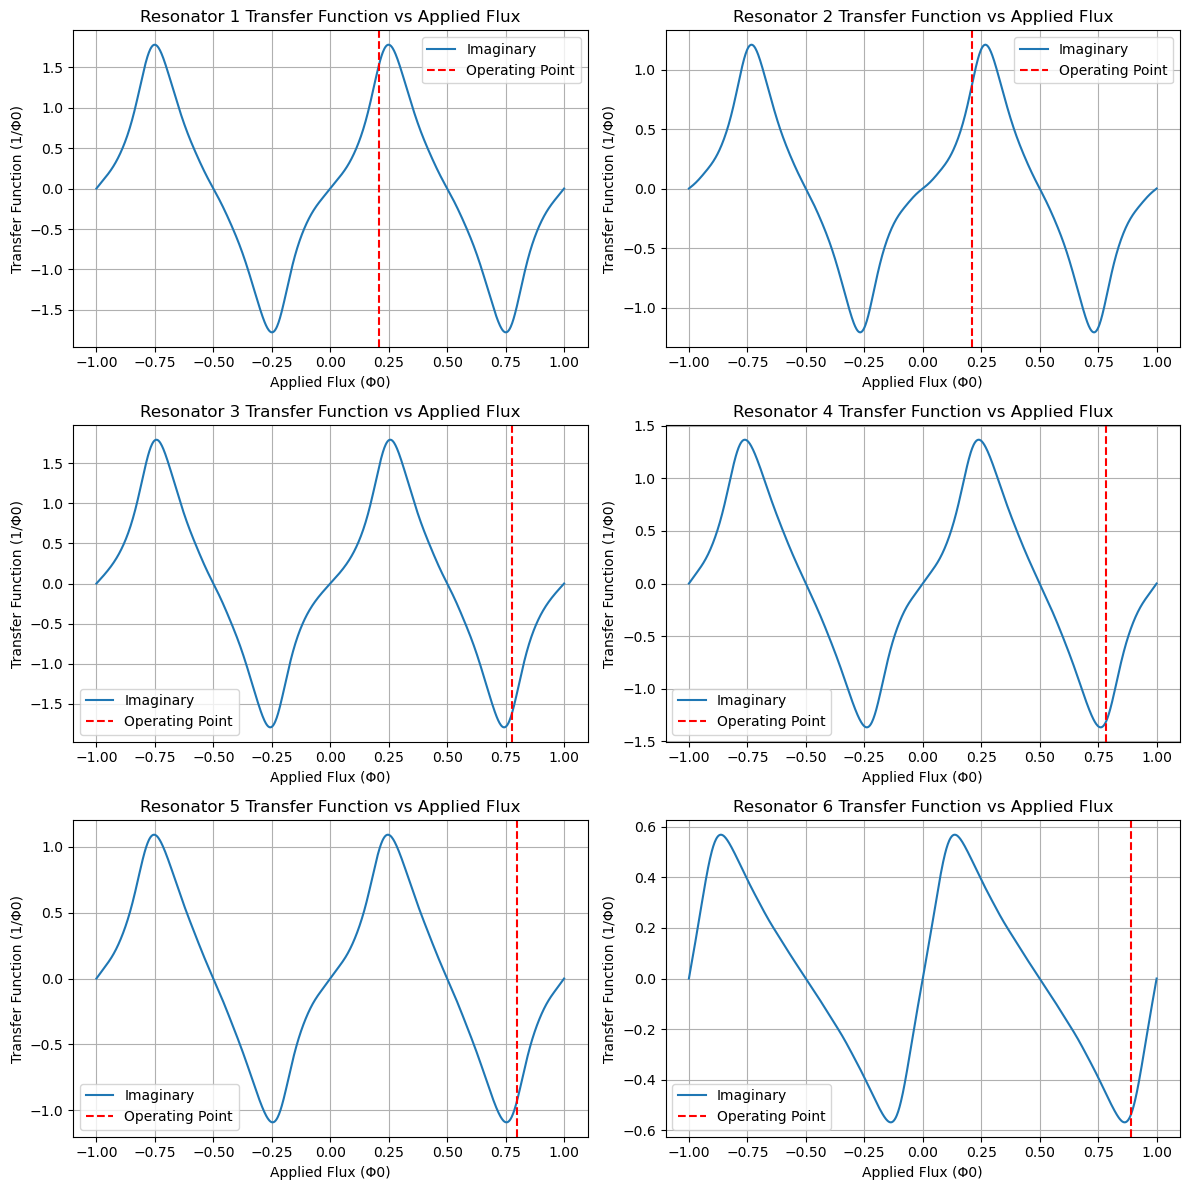

In [ ]:
# Plot the flux to S_21 transfer function as a function of applied flux bias for each resonator
fig, ax = plt.subplots(3, 2, figsize=(12, 12))
ax = ax.flatten()
phi_ext = np.linspace(-1, 1, 1000)
for i in range(res_num):
    res = TES3W12S9[i]
    tf = np.zeros(len(phi_ext))
    for j in range(len(phi_ext)):
        tf[j] = res.S21_to_flux_analytic(f_exc=operating_pts['f_exc'][i], Phi_ext=phi_ext[j], P_exc_dBm=operating_pts['P_exc_dBm'][i], demod_domain='imag')
    ax[i].plot(phi_ext, tf, label='Imaginary')
    ax[i].set_xlabel('Applied Flux (Φ0)')
    ax[i].set_ylabel('Transfer Function (1/Φ0)')
    ax[i].set_title(f'Resonator {i+1} Transfer Function vs Applied Flux')
    ax[i].grid(True)
    ax[i].axvline(operating_pts['Phi_ext'][i], color='red', linestyle='--', label='Operating Point')
    ax[i].legend()
plt.tight_layout()